# Condition Sweep Analysis: Lab vs Physics-Augmented vs GAN vs Combined

Results of the training sweep run on DGX
(`dgx_run_ml_sweep.sh` + `dgx_run_dl_sweep.sh` which run `training/tune_ml_hparams.py`
and `training/tune_dl_hparams.py`)

They train on each data set to see which feature set, generalizes best for each condition.

## The 4 conditions

| Condition | Data | n | Evaluation protocol |
|---|---|---|---|
| `lab` | 40 real lab signals | 40 | Leave-One-Out (40 folds) |
| `physics_aug` | Physics-informed augmented signals | 300 | 5-fold CV (~80/20 per fold) |
| `gan` | WGAN-GP(real) + TimeGAN(real) | 600 | 5-fold CV |
| `combined` | real (40) + physics-aug (300) + GAN (600) | 940 | 5-fold CV |

`lab` LOO
other three conditions use 5-fold CV

## Feature sets

Every condition is swept across the 3 existing feature suites
`core` (4 features), `extended` (7), `experimental` (23, per
`augmentation_pipeline.FEATURE_COLUMNS_BY_SUITE`) 
(raw data for 1D CNN)

## Models

6 classic ML regressors with `GridSearchCV` (ridge, elastic_net, decision_tree, random_forest)
and with `BayesSearchCV` (svr, xgboost) 
Also with Optuna MLP + 1D-CNN

## content
Load the sweep results, check completeness, and compare MAE across models/suites/
conditions.
Augmentation quality, `physics_aug`/`gan` if they look like real data.
Learning curves if they need more data.
SHAP 



In [1]:
# for root anchor (notebook moved into subfolder)
import sys
from pathlib import Path
ROOT_DIR = Path().resolve().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import paths
from plot_style import apply_default_plotly_layout
from run_condition_sweep import discover_jobs_flat, parse_result

CONDITIONS = ['lab', 'physics_aug', 'gan', 'combined']
CONDITION_LABELS = {
    'lab': 'Lab only (n=40, LOO)',
    'physics_aug': 'Physics-augmented only (n=300, 5-fold)',
    'gan': 'GAN only (n=600, 5-fold)',
    'combined': 'Combined: real+physics-aug+GAN (n=940, 5-fold)',
}
SUITES = ['core', 'extended', 'experimental']
SUITE_N_FEATURES = {'core': 4, 'extended': 7, 'experimental': 23}
ML_MODELS = ['ridge', 'elastic_net', 'decision_tree', 'random_forest', 'svr', 'xgboost']
ALL_MODELS = ML_MODELS + ['mlp', 'cnn']

# Fixed per-model color (categorical identity, never re-cycled), extending the
# palette model_evaluation.ipynb already uses so charts stay visually consistent
# across notebooks.
MODEL_COLORS = {
    'ridge': '#17becf', 'elastic_net': '#bcbd22', 'decision_tree': '#8c564b',
    'random_forest': '#e34a1a', 'svr': '#2ca02c', 'xgboost': '#5a23c4',
    'mlp': '#0b5fa5', 'cnn': '#a83279',
}

## 1. Load every result file found under `models/`

In [2]:
jobs = discover_jobs_flat(paths.MODELS_DIR)
rows = [r for r in (parse_result(job) for job in jobs) if r is not None]
df = pd.DataFrame(rows)
df['condition_label'] = df['condition'].map(CONDITION_LABELS)

print(f"Loaded {len(df)} (condition, suite, model) results from {paths.MODELS_DIR}")
df.sort_values(['condition', 'suite', 'model']).reset_index(drop=True)

Loaded 92 (condition, suite, model) results from C:\Users\Sorana\Desktop\licenta\MY_PROJECT_PYOCIANINA\pyocyanin-ai\models


,condition,model_type,model,suite,n_features,search_method,mae,rmse,r2,n_samples,best_params,condition_label
0,combined,ml,decision_tree,core,4,grid,0.929469,2.711463,0.984546,940,"{""decisiontreeregressor__ccp_alpha"": 0.0, ""dec...","Combined: real+physics-aug+GAN (n=940, 5-fold)"
1,combined,ml,elastic_net,core,4,grid,1.121849,2.553604,0.986293,940,"{""elasticnet__alpha"": 0.01, ""elasticnet__l1_ra...","Combined: real+physics-aug+GAN (n=940, 5-fold)"
2,combined,mlp,mlp,core,4,optuna,3.256824,8.078326,0.862826,752,"{""lr"": 0.00955507982823572, ""n_layers"": 3, ""hi...","Combined: real+physics-aug+GAN (n=940, 5-fold)"
3,combined,ml,random_forest,core,4,grid,0.775594,2.273543,0.989135,940,"{""randomforestregressor__max_depth"": null, ""ra...","Combined: real+physics-aug+GAN (n=940, 5-fold)"
4,combined,ml,ridge,core,4,grid,1.122216,2.541891,0.986419,940,"{""ridge__alpha"": 1.0, ""ridge__fit_intercept"": ...","Combined: real+physics-aug+GAN (n=940, 5-fold)"
...,...,...,...,...,...,...,...,...,...,...,...,...
87,physics_aug,ml,random_forest,extended,7,grid,0.306103,0.839188,0.998286,300,"{""randomforestregressor__max_depth"": null, ""ra...","Physics-augmented only (n=300, 5-fold)"
88,physics_aug,ml,ridge,extended,7,grid,0.578272,0.981122,0.997658,300,"{""ridge__alpha"": 0.001, ""ridge__fit_intercept""...","Physics-augmented only (n=300, 5-fold)"
89,physics_aug,ml,svr,extended,7,bayes,0.303772,0.842830,0.998271,300,"{""svr__C"": 99.48719998234101, ""svr__epsilon"": ...","Physics-augmented only (n=300, 5-fold)"
90,physics_aug,ml,xgboost,extended,7,bayes,0.293791,0.809170,0.998407,300,"{""xgbregressor__colsample_bytree"": 0.6, ""xgbre...","Physics-augmented only (n=300, 5-fold)"


## 2. Data completeness

Which (condition, suite, model) combinations are still pending on DGX.

In [3]:
expected = set()
for c in CONDITIONS:
    for s in SUITES:
        for m in ML_MODELS + ['mlp']:
            expected.add((c, s, m))
    expected.add((c, 'raw_signal', 'cnn'))

have = set(zip(df['condition'], df['suite'], df['model']))
missing = sorted(expected - have)

print(f"{len(have)}/{len(expected)} (condition, suite, model) results available.")
if missing:
    print(f"\
{len(missing)} still pending:")
    missing_df = pd.DataFrame(missing, columns=['condition', 'suite', 'model'])
    for condition, group in missing_df.groupby('condition'):
        pending_desc = ', '.join(f"{s}/{m}" for s, m in zip(group['suite'], group['model']))
        print(f"  {condition}: {pending_desc}")
else:
    print("Nothing pending - full sweep complete.")

88/88 (condition, suite, model) results available.
Nothing pending - full sweep complete.


## 3. Best model per condition

For every condition, the best-performing (model, feature suite, search method) combination, ranked by nested/LOO-CV MAE (lower is better)

In [4]:
from IPython.display import display, Markdown

best_tables = {}
for condition in CONDITIONS:
    cond_df = df[df['condition'] == condition]
    if cond_df.empty:
        display(Markdown(f"### {CONDITION_LABELS[condition]}\
*No results yet.*"))
        continue
    best_idx = cond_df.groupby('model')['mae'].idxmin()
    best = cond_df.loc[best_idx].sort_values('mae')
    best = best[['model', 'suite', 'n_features', 'search_method', 'mae', 'rmse', 'r2', 'n_samples']]
    best_tables[condition] = best
    display(Markdown(f"### {CONDITION_LABELS[condition]}"))
    display(best.style.format({'mae': '{:.3f}', 'rmse': '{:.3f}', 'r2': '{:.4f}'}).hide(axis='index'))

### Lab only (n=40, LOO)

model,suite,n_features,search_method,mae,rmse,r2,n_samples
decision_tree,extended,7,grid,0.013,0.048,1.0000,40
xgboost,core,4,bayes,0.120,0.410,0.9998,40
ridge,extended,7,grid,0.377,0.634,0.9995,40
elastic_net,extended,7,grid,0.602,0.965,0.9988,40
random_forest,core,4,grid,1.000,1.972,0.9948,40
svr,core,4,bayes,2.173,4.251,0.9759,40
mlp,experimental,23,optuna,2.912,6.105,0.9504,32
cnn,raw_signal,229,optuna,9.154,17.852,0.5759,32


### Physics-augmented only (n=300, 5-fold)

model,suite,n_features,search_method,mae,rmse,r2,n_samples
random_forest,experimental,23,grid,0.272,0.804,0.9984,300
xgboost,core,4,bayes,0.288,0.770,0.9986,300
svr,core,4,bayes,0.301,0.899,0.9980,300
decision_tree,extended,7,grid,0.352,0.868,0.9982,300
ridge,experimental,23,grid,0.356,0.710,0.9988,300
elastic_net,experimental,23,grid,0.464,0.801,0.9984,300
mlp,experimental,23,optuna,1.555,4.181,0.9575,240
cnn,raw_signal,229,optuna,2.668,6.801,0.8875,240


### GAN only (n=600, 5-fold)

model,suite,n_features,search_method,mae,rmse,r2,n_samples
random_forest,experimental,23,grid,0.771,2.315,0.9890,596
svr,extended,7,bayes,0.781,2.625,0.9857,600
xgboost,experimental,23,bayes,0.798,2.291,0.9892,596
ridge,experimental,23,grid,0.954,2.323,0.9889,596
decision_tree,experimental,23,grid,0.984,2.878,0.9829,596
elastic_net,experimental,23,grid,1.044,2.496,0.9872,596
mlp,core,4,optuna,2.654,5.888,0.9283,480
cnn,raw_signal,229,optuna,3.195,7.350,0.8883,480


### Combined: real+physics-aug+GAN (n=940, 5-fold)

model,suite,n_features,search_method,mae,rmse,r2,n_samples
svr,experimental,23,bayes,0.656,2.236,0.9895,936
xgboost,experimental,23,bayes,0.660,2.005,0.9916,936
random_forest,experimental,23,grid,0.667,2.053,0.9912,936
decision_tree,extended,7,grid,0.928,2.625,0.9855,940
ridge,experimental,23,grid,0.943,2.229,0.9896,936
elastic_net,extended,7,grid,0.955,2.412,0.9878,940
cnn,raw_signal,229,optuna,2.763,6.905,0.8998,752
mlp,experimental,23,optuna,2.926,7.097,0.8944,748


### 3.1 Visual comparison: best MAE per model, per condition

One panel per condition, same model always the same color across all four (and across
every other chart in this notebook).

In [5]:
fig = make_subplots(rows=2, cols=2, subplot_titles=[CONDITION_LABELS[c] for c in CONDITIONS])
legend_shown = set()

for i, condition in enumerate(CONDITIONS):
    row, col = i // 2 + 1, i % 2 + 1
    best = best_tables.get(condition)
    if best is None or best.empty:
        continue
    ordered = best.set_index('model').reindex([m for m in ALL_MODELS if m in best['model'].values]).reset_index()
    for _, r in ordered.iterrows():
        show_legend = r['model'] not in legend_shown
        legend_shown.add(r['model'])
        fig.add_trace(
            go.Bar(x=[r['model']], y=[r['mae']], name=r['model'], legendgroup=r['model'],
                   marker_color=MODEL_COLORS.get(r['model'], '#999999'), showlegend=show_legend,
                   text=[f"{r['mae']:.2f}"], textposition='outside'),
            row=row, col=col)

# apply_default_plotly_layout's xaxis_title/yaxis_title defaults are 'Potential
# E (V)'/'Current I (µA)' (this project's voltammogram convention) - this chart's
# axes are model name / MAE, so both are explicitly overridden (None/None) here
# *before* the real titles are set, instead of leaving the wrong defaults to
# silently apply as happened before this fix.
fig = apply_default_plotly_layout(fig, title_text='Best MAE per model, per condition',
                                   xaxis_title=None, yaxis_title=None)
fig.update_layout(barmode='group')
fig.update_yaxes(title_text='MAE (uM), lower = better')
fig.show()

## 4. Feature-count accuracy matrix

if adding more features help, and if it depends by data amount. 
Table and heatmap sweeps all 3 suites across (ML models only - MLP/CNN are shown separately bcs of raw data).

In [6]:
ml_df = df[df['model'].isin(ML_MODELS)]
matrix = (ml_df.groupby(['condition', 'suite', 'n_features', 'model'], as_index=False)['mae']
          .min())

paths.CONDITIONS_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
matrix.to_csv(paths.CONDITIONS_RESULTS_DIR / 'feature_count_accuracy_matrix.csv', index=False)
matrix.sort_values(['condition', 'n_features', 'model']).reset_index(drop=True)

,condition,suite,n_features,model,mae
0,combined,core,4,decision_tree,0.929469
1,combined,core,4,elastic_net,1.121849
2,combined,core,4,random_forest,0.775594
3,combined,core,4,ridge,1.122216
4,combined,core,4,svr,0.897849
...,...,...,...,...,...
67,physics_aug,experimental,23,elastic_net,0.463763
68,physics_aug,experimental,23,random_forest,0.272281
69,physics_aug,experimental,23,ridge,0.355597
70,physics_aug,experimental,23,svr,0.372135


### 4.1 Heatmap: MAE by feature count x model, per condition

One panel per condition, color-scaled independently (different MAE ranges) 
- dark = higher (worse) MAE within that panel

In [7]:
fig = make_subplots(rows=2, cols=2, subplot_titles=[CONDITION_LABELS[c] for c in CONDITIONS])

for i, condition in enumerate(CONDITIONS):
    row, col = i // 2 + 1, i % 2 + 1
    cond_matrix = matrix[matrix['condition'] == condition]
    if cond_matrix.empty:
        continue
    pivot = cond_matrix.pivot(index='model', columns='suite', values='mae').reindex(
        index=[m for m in ML_MODELS if m in cond_matrix['model'].values],
        columns=[s for s in SUITES if s in cond_matrix['suite'].values],
    )
    fig.add_trace(
        go.Heatmap(z=pivot.values, x=[f"{s} ({SUITE_N_FEATURES[s]})" for s in pivot.columns],
                   y=pivot.index, colorscale='Blues', showscale=False,
                   text=pivot.values, texttemplate='%{text:.2f}'),
        row=row, col=col)

# See the note in the previous chart's cell - apply_default_plotly_layout's E/I
# defaults are overridden (None) here since this is a suite x model heatmap, not
# a voltammogram.
fig = apply_default_plotly_layout(fig, title_text='MAE (uM) by feature suite x model, per condition (lower = better)',
                                   xaxis_title=None, yaxis_title=None)
fig.update_layout(height=700)
fig.update_xaxes(title_text='feature suite (n features)')
fig.show()

## 5. if more data helps the same model

Each model's best MAE (from section 3's tables) across the 4 conditions, ordered by pool size (lab=40 -> physics_aug=300 -> gan=600 -> combined=940). 
If the  strategy works, MAE should go down as more data is added 


(`lab` is LOO while the other three are 5-fold CV so keep in mind when comparing)

In [ ]:
best_long = pd.concat(
    [t.assign(condition=c) for c, t in best_tables.items() if not t.empty],
    ignore_index=True,
) if best_tables else pd.DataFrame()

fig = go.Figure()
if not best_long.empty:
    for model in ALL_MODELS:
        sub = best_long[best_long['model'] == model].set_index('condition').reindex(CONDITIONS)
        if sub['mae'].isna().all():
            continue
        fig.add_trace(go.Bar(
            x=[CONDITION_LABELS[c] for c in CONDITIONS], y=sub['mae'], name=model,
            marker_color=MODEL_COLORS.get(model, '#999999'),
        ))

fig = apply_default_plotly_layout(fig, title_text='Best MAE per model, across conditions (growing data pool ->)',
                                   xaxis_title=None, yaxis_title='MAE (uM), lower = better')
fig.update_layout(barmode='group')
fig.show()

## 6. NEW: Overall winner and best-per-suite summary

used to figure out the best combination and which feature suite wins across conditions

Persist four per-condition best-model tables to `results/conditions/` as real CSV artifacts
(`{condition}_best_models.csv`, `all_runs_long.csv`, `overall_best_per_suite.csv`).

In [ ]:
paths.CONDITIONS_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

for condition, table in best_tables.items():
    table.to_csv(paths.condition_best_models_csv(condition), index=False)
df.to_csv(paths.CONDITIONS_RESULTS_DIR / 'all_runs_long.csv', index=False)

# Naive global minimum, across ALL 4 conditions (including lab)
naive_overall_best = df.loc[df['mae'].idxmin()]
print("Naive global best (condition, model, suite) by raw MAE, all 4 conditions included:")
print(naive_overall_best[['condition', 'model', 'suite', 'mae', 'rmse', 'r2', 'n_samples']].to_string())
print(
    "\
This picks 'lab'/decision_tree - already flagged in Section 8.1 as a memorisation "
    "artifact of LOO on 40 signals (train MAE collapses to 0 too), not a genuine "
    "generalisation win. The fair comparison below excludes 'lab' for the same reason "
    "Section 9 (SHAP) already does."
)

Naive global best (condition, model, suite) by raw MAE, all 4 conditions included:
condition              lab
model        decision_tree
suite             extended
mae               0.013214
rmse              0.048287
r2                0.999997
n_samples               40
This picks 'lab'/decision_tree - already flagged in Section 8.1 as a memorisation artifact of LOO on 40 signals (train MAE collapses to 0 too), not a genuine generalisation win. The fair comparison below excludes 'lab' for the same reason Section 9 (SHAP) already does.


In [ ]:
# NEW: fair overall winner (excluding lab) + best model per feature suite
comparable_df = df[df['condition'].isin(['physics_aug', 'gan', 'combined'])]

fair_overall_best = comparable_df.loc[comparable_df['mae'].idxmin()]
print("Overall best (condition, model, suite), excluding 'lab' (LOO/memorisation caveat):")
print(fair_overall_best[['condition', 'model', 'suite', 'mae', 'rmse', 'r2', 'n_samples']].to_string())

best_per_suite = (
    comparable_df[comparable_df['model'].isin(ML_MODELS)]
    .loc[lambda d: d.groupby('suite')['mae'].idxmin()]
    [['suite', 'n_features', 'condition', 'model', 'mae', 'rmse', 'r2']]
    .sort_values('n_features')
    .reset_index(drop=True)
)
best_per_suite.to_csv(paths.CONDITIONS_RESULTS_DIR / 'overall_best_per_suite.csv', index=False)
print("\
Best (condition, model) per feature suite, pooled across physics_aug/gan/combined:")
best_per_suite

Overall best (condition, model, suite), excluding 'lab' (LOO/memorisation caveat):
condition      physics_aug
model        random_forest
suite         experimental
mae               0.272281
rmse              0.804205
r2                0.998426
n_samples              300
Best (condition, model) per feature suite, pooled across physics_aug/gan/combined:


,suite,n_features,condition,model,mae,rmse,r2
0,core,4,physics_aug,xgboost,0.287564,0.770481,0.998555
1,extended,7,physics_aug,xgboost,0.293791,0.809170,0.998407
2,experimental,23,physics_aug,random_forest,0.272281,0.804205,0.998426


In [11]:
# NEW: ranked chart of the top combinations by MAE (excluding lab), to visualise the
# overall winner and its margin over the runners-up
top_n = 15
ranked = comparable_df.nsmallest(top_n, 'mae').iloc[::-1]  # ascending so the smallest MAE ends up on top
ranked_labels = ranked['condition'] + ' / ' + ranked['model'] + ' (' + ranked['suite'] + ')'

fig = go.Figure(go.Bar(
    x=ranked['mae'], y=ranked_labels, orientation='h',
    marker_color=[MODEL_COLORS.get(m, '#999999') for m in ranked['model']],
    text=[f"{v:.3f}" for v in ranked['mae']], textposition='outside',
))
fig = apply_default_plotly_layout(
    fig, title_text=f'Top {top_n} (condition, model, suite) combinations by MAE (lab excluded)',
    xaxis_title='MAE (uM), lower = better', yaxis_title=None)
fig.update_layout(height=500)
fig.show()

## 7. Similarity with data

if the `physics_aug` and `gan` signals look like the 40 real lab signals.

- **7.1 Signal-shape overlay** 
(intuitive visual overlay check). Real I(E) curves vs. synthetic ones at matching concentrations, overlaid directly.
- **7.2 Shape-feature distribution overlap** 
Histograms of shape descriptors (peak potential, FWHM, asymmetry), pooled across all concentrations. 
Exclude `peak_current`/`peak_AUC` because they scale with concentration.

### 7.1 Signal-shape overlay: real vs. synthetic I(E) curves at matching concentrations

`physics_aug`/`gan` concentrations are drawn from log-uniform range, so "matching concentration" means the synthetic signals within +-15% of each anchor.

In [12]:
import numpy as np

def load_raw_signals(csv_path):
    d = pd.read_csv(csv_path)
    I_cols = [c for c in d.columns if c.startswith('I_')]
    return d[I_cols].to_numpy(dtype=float), d['concentration'].to_numpy(dtype=float)

E_grid = pd.read_csv(paths.POTENTIAL_GRID_CSV).to_numpy(dtype=float).flatten()
X_real, y_real = load_raw_signals(paths.REAL_SIGNALS_CSV)
X_physics_aug, y_physics_aug = load_raw_signals(paths.AUGMENTED_SIGNALS_CSV)
X_gan, y_gan = load_raw_signals(paths.GAN_ONLY_RAW_SIGNALS_CSV)

SYNTH_SOURCES = {
    'physics_aug': ('Physics-augmented', X_physics_aug, y_physics_aug, '#e34a1a', 'dash'),
    'gan': ('GAN (WGAN-GP + TimeGAN)', X_gan, y_gan, '#5a23c4', 'dashdot'),
}
ANCHOR_CONCS_UM = [0.5, 10.0, 50.0]  # low / mid / high, all real classes (see section 7 note)


def signals_near(X, y, target, tol, max_n=6, seed=0):
    mask = np.abs(y - target) <= tol * target
    idx = np.where(mask)[0]
    rng = np.random.default_rng(seed)
    if len(idx) > max_n:
        idx = rng.choice(idx, size=max_n, replace=False)
    return X[idx]


fig = make_subplots(rows=1, cols=len(ANCHOR_CONCS_UM),
                     subplot_titles=[f'~{c:g} uM' for c in ANCHOR_CONCS_UM])

for col_i, conc in enumerate(ANCHOR_CONCS_UM, start=1):
    for j, curve in enumerate(signals_near(X_real, y_real, conc, tol=0.05)):
        fig.add_trace(go.Scatter(
            x=E_grid, y=curve, mode='lines', line=dict(color='black', width=2.2), opacity=0.85,
            name='Real (lab)', legendgroup='real', showlegend=(col_i == 1 and j == 0)),
            row=1, col=col_i)
    for key, (label, Xs, ys, color, dash) in SYNTH_SOURCES.items():
        for j, curve in enumerate(signals_near(Xs, ys, conc, tol=0.15, seed=hash(key) % 1000)):
            fig.add_trace(go.Scatter(
                x=E_grid, y=curve, mode='lines', line=dict(color=color, width=1.4, dash=dash),
                opacity=0.55, name=label, legendgroup=key, showlegend=(col_i == 1 and j == 0)),
                row=1, col=col_i)

fig = apply_default_plotly_layout(fig, title_text='Real vs. synthetic signal shape overlap, by concentration',
                                   xaxis_title=None, yaxis_title=None)
fig.update_xaxes(title_text='Potential E (V)')
fig.update_yaxes(title_text='Current I (uA)', col=1)
fig.show()

Only one concentration per graph for documentation

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def load_raw_signals(csv_path):
    d = pd.read_csv(csv_path)
    I_cols = [c for c in d.columns if c.startswith('I_')]
    return d[I_cols].to_numpy(dtype=float), d['concentration'].to_numpy(dtype=float)

E_grid = pd.read_csv(paths.POTENTIAL_GRID_CSV).to_numpy(dtype=float).flatten()
X_real, y_real = load_raw_signals(paths.REAL_SIGNALS_CSV)
X_physics_aug, y_physics_aug = load_raw_signals(paths.AUGMENTED_SIGNALS_CSV)
X_gan, y_gan = load_raw_signals(paths.GAN_ONLY_RAW_SIGNALS_CSV)

SYNTH_SOURCES = {
    'physics_aug': ('Physics-augmented', X_physics_aug, y_physics_aug, '#e34a1a', 'dash'),
    'gan': ('GAN (WGAN-GP + TimeGAN)', X_gan, y_gan, '#5a23c4', 'dashdot'),
}

ANCHOR_CONCS_UM = [10.0]  

def signals_near(X, y, target, tol, max_n=6, seed=0):
    mask = np.abs(y - target) <= tol * target
    idx = np.where(mask)[0]
    rng = np.random.default_rng(seed)
    if len(idx) > max_n:
        idx = rng.choice(idx, size=max_n, replace=False)
    return X[idx]


fig = make_subplots(rows=1, cols=len(ANCHOR_CONCS_UM),
                     subplot_titles=[f'~{c:g} uM' for c in ANCHOR_CONCS_UM])

for col_i, conc in enumerate(ANCHOR_CONCS_UM, start=1):
    for j, curve in enumerate(signals_near(X_real, y_real, conc, tol=0.05)):
        fig.add_trace(go.Scatter(
            x=E_grid, y=curve, mode='lines', line=dict(color='black', width=2.2), opacity=0.85,
            name='Real (lab)', legendgroup='real', showlegend=(col_i == 1 and j == 0)),
            row=1, col=col_i)
    for key, (label, Xs, ys, color, dash) in SYNTH_SOURCES.items():
        for j, curve in enumerate(signals_near(Xs, ys, conc, tol=0.15, seed=hash(key) % 1000)):
            fig.add_trace(go.Scatter(
                x=E_grid, y=curve, mode='lines', line=dict(color=color, width=1.4, dash=dash),
                opacity=0.55, name=label, legendgroup=key, showlegend=(col_i == 1 and j == 0)),
                row=1, col=col_i)

fig = apply_default_plotly_layout(fig, title_text='Real vs. synthetic signal shape overlap',
                                   xaxis_title=None, yaxis_title=None)

# exclude noise
fig.update_xaxes(title_text='Potential E (V)', range=[E_grid.min(), 0.2])
fig.update_yaxes(title_text='Current I (uA)', col=1)
fig.show()

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def load_raw_signals(csv_path):
    d = pd.read_csv(csv_path)
    I_cols = [c for c in d.columns if c.startswith('I_')]
    return d[I_cols].to_numpy(dtype=float), d['concentration'].to_numpy(dtype=float)

E_grid = pd.read_csv(paths.POTENTIAL_GRID_CSV).to_numpy(dtype=float).flatten()
X_real, y_real = load_raw_signals(paths.REAL_SIGNALS_CSV)
X_physics_aug, y_physics_aug = load_raw_signals(paths.AUGMENTED_SIGNALS_CSV)
X_gan, y_gan = load_raw_signals(paths.GAN_ONLY_RAW_SIGNALS_CSV)

SYNTH_SOURCES = {
    'physics_aug': ('Physics-augmented', X_physics_aug, y_physics_aug, '#e34a1a', 'dash'),
    'gan': ('GAN (WGAN-GP + TimeGAN)', X_gan, y_gan, '#5a23c4', 'dashdot'),
}

ANCHOR_CONCS_UM = [50.0]  

def signals_near(X, y, target, tol, max_n=6, seed=0):
    mask = np.abs(y - target) <= tol * target
    idx = np.where(mask)[0]
    rng = np.random.default_rng(seed)
    if len(idx) > max_n:
        idx = rng.choice(idx, size=max_n, replace=False)
    return X[idx]


fig = make_subplots(rows=1, cols=len(ANCHOR_CONCS_UM),
                     subplot_titles=[f'~{c:g} uM' for c in ANCHOR_CONCS_UM])

for col_i, conc in enumerate(ANCHOR_CONCS_UM, start=1):
    for j, curve in enumerate(signals_near(X_real, y_real, conc, tol=0.05)):
        fig.add_trace(go.Scatter(
            x=E_grid, y=curve, mode='lines', line=dict(color='black', width=2.2), opacity=0.85,
            name='Real (lab)', legendgroup='real', showlegend=(col_i == 1 and j == 0)),
            row=1, col=col_i)
    for key, (label, Xs, ys, color, dash) in SYNTH_SOURCES.items():
        for j, curve in enumerate(signals_near(Xs, ys, conc, tol=0.15, seed=hash(key) % 1000)):
            fig.add_trace(go.Scatter(
                x=E_grid, y=curve, mode='lines', line=dict(color=color, width=1.4, dash=dash),
                opacity=0.55, name=label, legendgroup=key, showlegend=(col_i == 1 and j == 0)),
                row=1, col=col_i)

fig = apply_default_plotly_layout(fig, title_text='Real vs. synthetic signal shape overlap',
                                   xaxis_title=None, yaxis_title=None)

# exclude noise
fig.update_xaxes(title_text='Potential E (V)', range=[E_grid.min(), 0.2])
fig.update_yaxes(title_text='Current I (uA)', col=1)
fig.show()

In [ ]:
# number comparison for each anchor concentration: 
# RMSE of each synthetic source's mean curve against the real mean curve
for conc in ANCHOR_CONCS_UM:
    real_mean = signals_near(X_real, y_real, conc, tol=0.05, max_n=10_000).mean(axis=0)
    print(f"{conc:g} uM  |  real peak={real_mean.max():.2f} uA", end='')
    for key, (label, Xs, ys, _, _) in SYNTH_SOURCES.items():
        synth_mean = signals_near(Xs, ys, conc, tol=0.15, max_n=10_000).mean(axis=0)
        rmse = float(np.sqrt(np.mean((synth_mean - real_mean) ** 2)))
        print(f"  |  {label} peak={synth_mean.max():.2f} uA (RMSE vs. real={rmse:.3f})", end='')
    print()

0.5 uM  |  real peak=1.99 uA  |  Physics-augmented peak=1.75 uA (RMSE vs. real=0.038)  |  GAN (WGAN-GP + TimeGAN) peak=1.91 uA (RMSE vs. real=0.077)
10 uM  |  real peak=4.02 uA  |  Physics-augmented peak=3.83 uA (RMSE vs. real=0.065)  |  GAN (WGAN-GP + TimeGAN) peak=4.03 uA (RMSE vs. real=0.103)
50 uM  |  real peak=22.78 uA  |  Physics-augmented peak=21.09 uA (RMSE vs. real=0.310)  |  GAN (WGAN-GP + TimeGAN) peak=23.06 uA (RMSE vs. real=0.190)


### 7.2 Shape-feature distribution overlap (real vs. physics-aug vs. GAN, pooled)

`peak_potential` (Ep), `peak_FWHM` and `asymetry` from the `experimental` suite - the same
three concentration-independent shape descriptors `validation_metrics.SHAPE_KEYS` uses -
pooled across every concentration in each condition.

In [14]:
SHAPE_FEATURES = ['peak_potential', 'peak_FWHM', 'asymetry']

feat_real = pd.read_csv(paths.VECTORIZED_EXPERIMENTAL_CSV)
feat_physics_aug = pd.read_csv(paths.VECTORIZED_DIR / 'full_augmented_experimental.csv')
feat_gan = pd.read_csv(paths.gan_only_features_csv('experimental'))

FEATURE_DIST_SOURCES = [
    ('Real (lab)', feat_real, '#333333'),
    ('Physics-augmented', feat_physics_aug, '#e34a1a'),
    ('GAN', feat_gan, '#5a23c4'),
]

fig = make_subplots(rows=1, cols=len(SHAPE_FEATURES), subplot_titles=SHAPE_FEATURES)
for col_i, feat in enumerate(SHAPE_FEATURES, start=1):
    for label, d, color in FEATURE_DIST_SOURCES:
        fig.add_trace(go.Histogram(
            x=d[feat], histnorm='probability density', name=label, marker_color=color,
            opacity=0.5, legendgroup=label, showlegend=(col_i == 1)),
            row=1, col=col_i)

fig.update_layout(barmode='overlay')
fig = apply_default_plotly_layout(fig, title_text='Shape-feature distribution overlap (pooled across concentrations)',
                                   xaxis_title=None, yaxis_title=None)
fig.update_yaxes(title_text='density', col=1)
fig.show()

In [15]:
# Quantifies what the histograms above show visually: two-sample Kolmogorov-Smirnov
# test (real vs. each synthetic source), per shape feature.
from scipy.stats import ks_2samp

for feat in SHAPE_FEATURES:
    r = feat_real[feat]
    print(f"{feat}: real mean={r.mean():.4f} std={r.std():.4f}")
    for label, d, _ in FEATURE_DIST_SOURCES[1:]:
        stat = ks_2samp(r, d[feat])
        flag = '*significant*' if stat.pvalue < 0.05 else 'not significant'
        print(f"    vs. {label}: mean={d[feat].mean():.4f} std={d[feat].std():.4f}  "
              f"KS p={stat.pvalue:.4f} ({flag})")

peak_potential: real mean=-0.3814 std=0.0155
    vs. Physics-augmented: mean=-0.3807 std=0.0194  KS p=0.2152 (not significant)
    vs. GAN: mean=-0.3869 std=0.0129  KS p=0.0506 (not significant)
peak_FWHM: real mean=0.0586 std=0.0078
    vs. Physics-augmented: mean=0.0607 std=0.0132  KS p=0.0663 (not significant)
    vs. GAN: mean=0.0659 std=0.0184  KS p=0.0042 (*significant*)
asymetry: real mean=1.0143 std=0.5318
    vs. Physics-augmented: mean=1.2897 std=1.8908  KS p=0.0596 (not significant)
    vs. GAN: mean=1.3206 std=1.2219  KS p=0.0135 (*significant*)


## 8. Learning curves

Uses a plain 5-fold CV for every condition (including `lab`) just to make the four curves visually comparable on the same x-axis convention

In [ ]:
import json

TRAINING_DIR = ROOT_DIR / 'training'
if str(TRAINING_DIR) not in sys.path:
    sys.path.append(str(TRAINING_DIR))

from tune_ml_hparams import build_model_specs 
from run_condition_sweep import CONDITIONS as CONDITION_PATHS

from sklearn.base import clone
from sklearn.model_selection import KFold, learning_curve

MODEL_SPECS = build_model_specs(seed=42)


def load_condition_features(condition: str, suite: str) -> tuple[pd.DataFrame, pd.Series]:
    d = pd.read_csv(CONDITION_PATHS[condition]['features'][suite])
    drop = [c for c in ['sig_id'] if c in d.columns] + ['concentration']
    return d.drop(columns=drop), d['concentration']


def best_params_for(condition: str, model: str, suite: str) -> dict:
    row = df[(df['condition'] == condition) & (df['model'] == model) & (df['suite'] == suite)].iloc[0]
    return json.loads(row['best_params'])


LEARNING_CURVE_TRAIN_FRACTIONS = np.linspace(0.2, 1.0, 6)
learning_curve_data = {}

fig = make_subplots(rows=2, cols=2, subplot_titles=[CONDITION_LABELS[c] for c in CONDITIONS])

for i, condition in enumerate(CONDITIONS):
    row_i, col_i = i // 2 + 1, i % 2 + 1
    best = best_tables.get(condition)
    if best is None or best.empty:
        continue
    top = best.iloc[0]
    model_name, suite = top['model'], top['suite']

    X, y = load_condition_features(condition, suite)
    pipe = clone(MODEL_SPECS[model_name]['pipeline'])
    pipe.set_params(**best_params_for(condition, model_name, suite))

    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X, y, train_sizes=LEARNING_CURVE_TRAIN_FRACTIONS,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        scoring='neg_mean_absolute_error', n_jobs=-1)
    train_mae, val_mae = -train_scores.mean(axis=1), -val_scores.mean(axis=1)
    learning_curve_data[condition] = dict(model=model_name, suite=suite, train_sizes=train_sizes,
                                           train_mae=train_mae, val_mae=val_mae)

    color = MODEL_COLORS.get(model_name, '#999999')
    fig.add_trace(go.Scatter(x=train_sizes, y=train_mae, mode='lines+markers',
                              name=f'{condition}: {model_name} (train)',
                              line=dict(color=color, dash='dot')), row=row_i, col=col_i)
    fig.add_trace(go.Scatter(x=train_sizes, y=val_mae, mode='lines+markers',
                              name=f'{condition}: {model_name} (5-fold CV)',
                              line=dict(color=color)), row=row_i, col=col_i)

fig = apply_default_plotly_layout(fig, title_text="Learning curves: each condition's best model (train vs. 5-fold CV MAE)",
                                   xaxis_title=None, yaxis_title=None)
fig.update_xaxes(title_text='training set size (signals)')
fig.update_yaxes(title_text='MAE (uM)', col=1)
fig.show()

In [ ]:
# Numeric summary of the curves above
for condition in CONDITIONS:
    d = learning_curve_data.get(condition)
    if d is None:
        continue
    section3_mae = best_tables[condition].iloc[0]['mae']
    print(f"{condition} ({d['model']}, {d['suite']}): "
          f"smallest fold train={d['train_sizes'][0]} -> val MAE={d['val_mae'][0]:.3f} uM | "
          f"full size train={d['train_sizes'][-1]} -> val MAE={d['val_mae'][-1]:.3f} uM "
          f"(Section 3 nested-CV MAE={section3_mae:.3f}) | "
          f"final train/val gap={d['val_mae'][-1] - d['train_mae'][-1]:.3f}")

lab (decision_tree, extended): smallest fold train=6 -> val MAE=28.756 uM | full size train=32 -> val MAE=0.000 uM (Section 3 nested-CV MAE=0.013) | final train/val gap=0.000
physics_aug (random_forest, experimental): smallest fold train=48 -> val MAE=10.062 uM | full size train=240 -> val MAE=0.285 uM (Section 3 nested-CV MAE=0.272) | final train/val gap=0.190
gan (random_forest, experimental): smallest fold train=95 -> val MAE=1.916 uM | full size train=476 -> val MAE=0.777 uM (Section 3 nested-CV MAE=0.771) | final train/val gap=0.481
combined (svr, experimental): smallest fold train=149 -> val MAE=3.145 uM | full size train=748 -> val MAE=0.656 uM (Section 3 nested-CV MAE=0.656) | final train/val gap=0.215


## 9. SHAP

SHAP says why it predicts what it predicts. Interprets the top 3 tuned models from the three conditions (`physics_aug`, `gan`, `combined` - all 5-fold CV; `lab` excluded here for the same LOO-vs-kfold reason )
Each condition's own Section-3 winner, refit locally with saved `best_params`.

- 9.1 Global importance - beeswarm summary plot + bar plot, per model.
- 9.2 Local explanation - waterfall + force plot for one concrete prediction.
- 9.3 Dependence (scatter) plots for the top few features 

In [18]:
import shap

SHAP_CONDITIONS = ['physics_aug', 'gan', 'combined']  # 'lab' excluded - see markdown above
N_SHAP_SAMPLES = 150
SHAP_SEED = 42
TREE_MODELS = {'decision_tree', 'random_forest', 'xgboost'}


def fit_condition_best(condition: str):
    top = best_tables[condition].iloc[0]
    model_name, suite = top['model'], top['suite']
    X, y = load_condition_features(condition, suite)
    pipe = clone(MODEL_SPECS[model_name]['pipeline'])
    pipe.set_params(**best_params_for(condition, model_name, suite))
    pipe.fit(X, y)
    return dict(condition=condition, model=model_name, suite=suite, pipe=pipe, X=X, y=y)


def tree_step_and_input(fitted: dict):
    """The raw fitted regressor + the X exactly as it reaches that regressor
    (xgboost's pipeline has a SimpleImputer in front of it; decision_tree/
    random_forest take X directly - see build_model_specs in tune_ml_hparams.py)."""
    pipe, X = fitted['pipe'], fitted['X']
    step_name = next(n for n in pipe.named_steps if n != 'simpleimputer')
    X_in = X
    if 'simpleimputer' in pipe.named_steps:
        X_in = pd.DataFrame(pipe.named_steps['simpleimputer'].transform(X), columns=X.columns, index=X.index)
    return pipe.named_steps[step_name], X_in


def sample_rows(X: pd.DataFrame, y: pd.Series, n: int, seed: int):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=min(n, len(X)), replace=False)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)


shap_results = {}
for condition in SHAP_CONDITIONS:
    fitted = fit_condition_best(condition)
    model_name = fitted['model']

    if model_name in TREE_MODELS:
        regressor, X_full_in = tree_step_and_input(fitted)
        X_sample, y_sample = sample_rows(X_full_in, fitted['y'], N_SHAP_SAMPLES, SHAP_SEED)
        explainer = shap.TreeExplainer(regressor)
    else:
        X_sample, y_sample = sample_rows(fitted['X'], fitted['y'], N_SHAP_SAMPLES, SHAP_SEED)
        background = shap.sample(fitted['X'], 50, random_state=SHAP_SEED)
        explainer = shap.Explainer(fitted['pipe'].predict, background, seed=SHAP_SEED)

    shap_values = explainer(X_sample)
    shap_results[condition] = dict(**fitted, X_sample=X_sample, y_sample=y_sample,
                                    explainer=explainer, shap_values=shap_values)
    print(f"[{condition}] {model_name} on '{fitted['suite']}' ({fitted['X'].shape[1]} features) - "
          f"explained {len(X_sample)} sampled signals")

C:\Users\Sorana\Desktop\licenta\MY_PROJECT_PYOCIANINA\pyocyanin-ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[physics_aug] random_forest on 'experimental' (23 features) - explained 150 sampled signals


[gan] random_forest on 'experimental' (23 features) - explained 150 sampled signals



PermutationExplainer explainer:   1%|          | 1/150 [00:00<?, ?it/s]


PermutationExplainer explainer:   2%|▏         | 3/150 [00:23<03:39,  1.50s/it]

...


PermutationExplainer explainer:  99%|█████████▉| 149/150 [07:16<00:03,  3.67s/it]


PermutationExplainer explainer: 100%|██████████| 150/150 [07:22<00:00,  4.54s/it]


PermutationExplainer explainer: 151it [07:27,  4.54s/it]                         


PermutationExplainer explainer: 151it [07:27,  2.98s/it]

[combined] svr on 'experimental' (23 features) - explained 150 sampled signals


### 9.1 Global explanation: summary (beeswarm) + bar plot, per model

Beeswarm: each dot = one signal; its position on the x-axis is that feature's SHAP contribution to that prediction (uM pushed up/down), colour is the feature's own value (red = high, blue = low)

Colour vs. x-position together show the direction of theeffect. Bar: mean |SHAP value| per feature, ranked.

C:\Users\Sorana\AppData\Local\Temp\ipykernel_14276\4036230919.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(r['shap_values'], r['X_sample'], show=False)


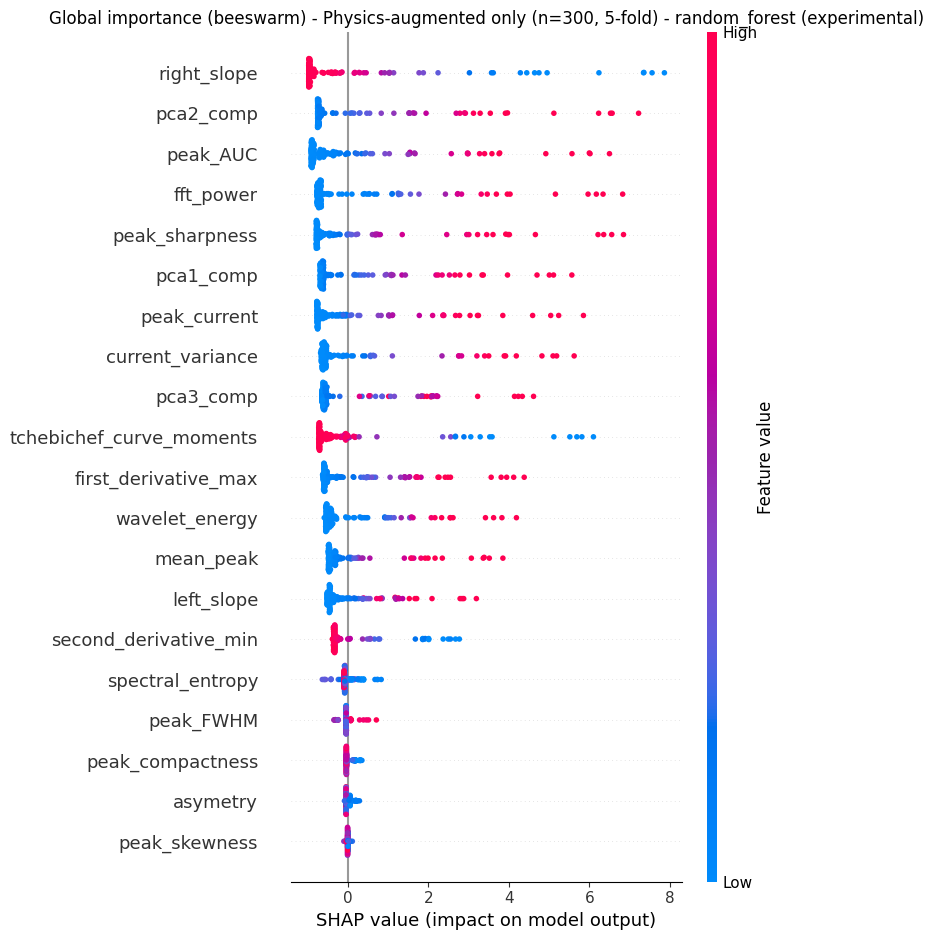

C:\Users\Sorana\AppData\Local\Temp\ipykernel_14276\4036230919.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(r['shap_values'], r['X_sample'], plot_type='bar', show=False)


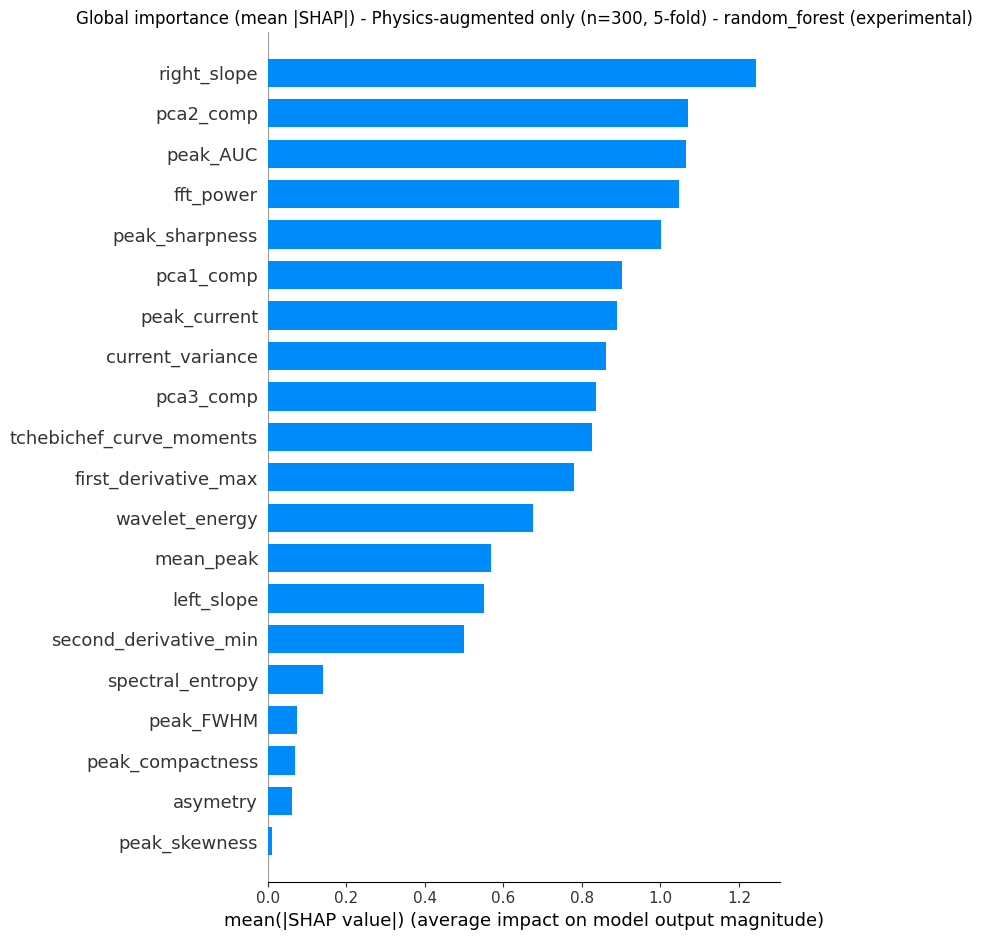

C:\Users\Sorana\AppData\Local\Temp\ipykernel_14276\4036230919.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(r['shap_values'], r['X_sample'], show=False)


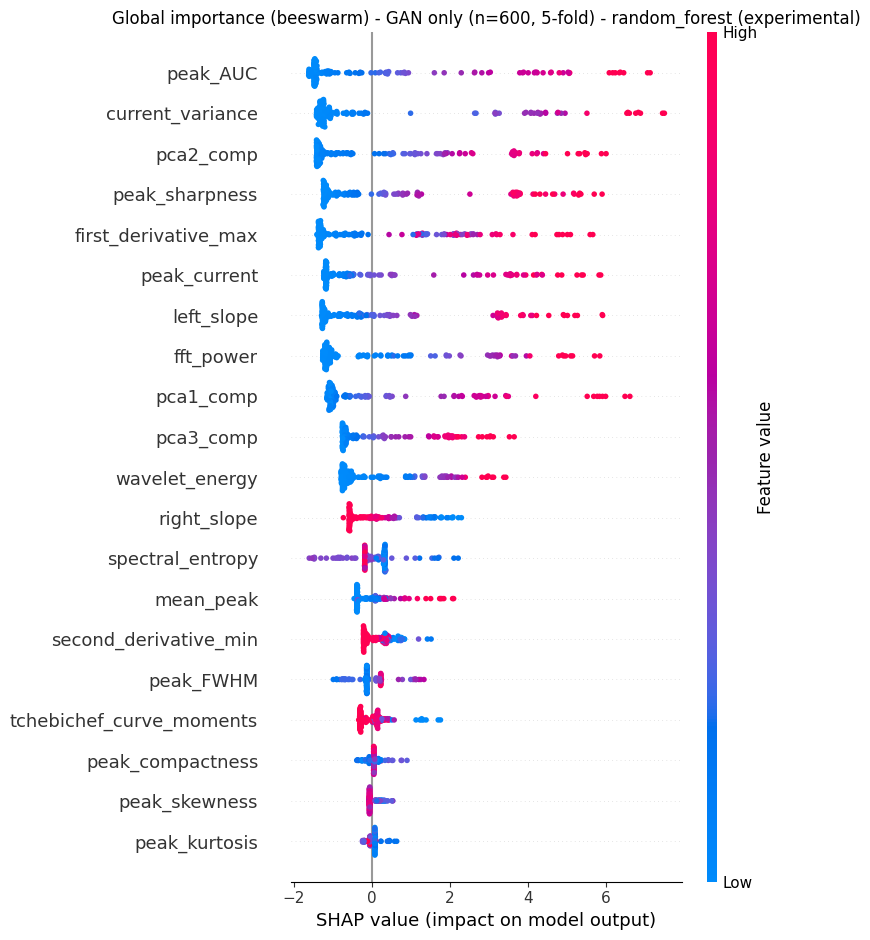

C:\Users\Sorana\AppData\Local\Temp\ipykernel_14276\4036230919.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(r['shap_values'], r['X_sample'], plot_type='bar', show=False)


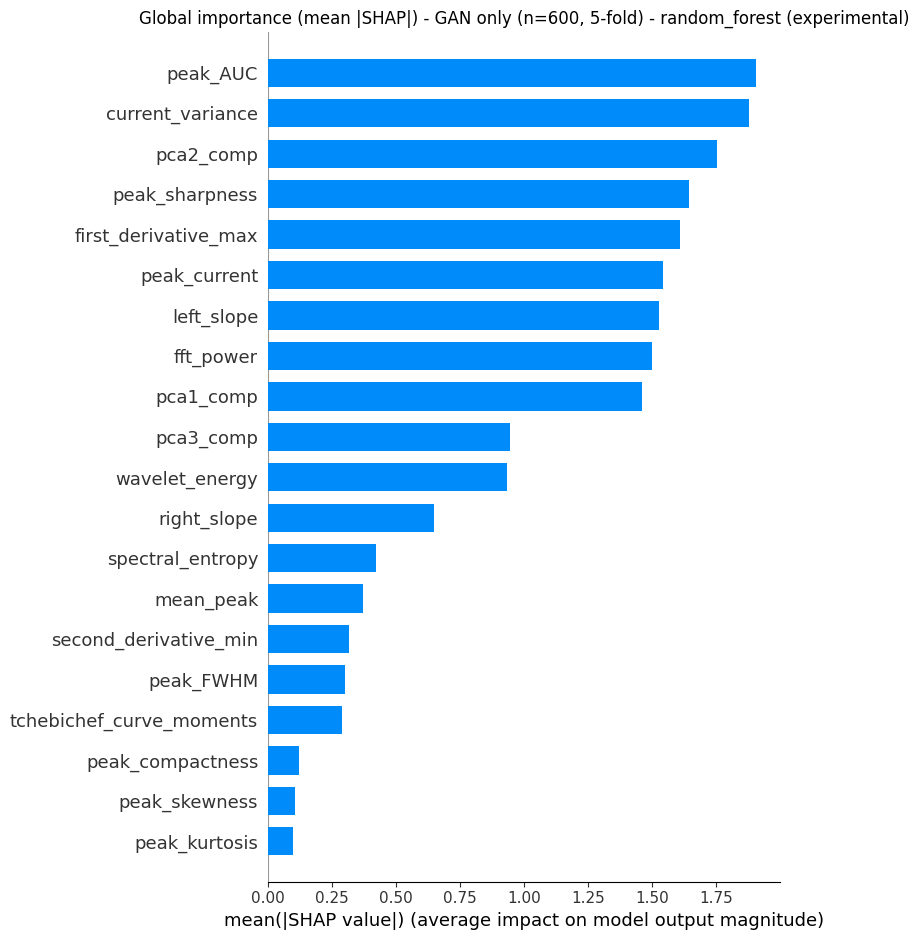

C:\Users\Sorana\AppData\Local\Temp\ipykernel_14276\4036230919.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(r['shap_values'], r['X_sample'], show=False)


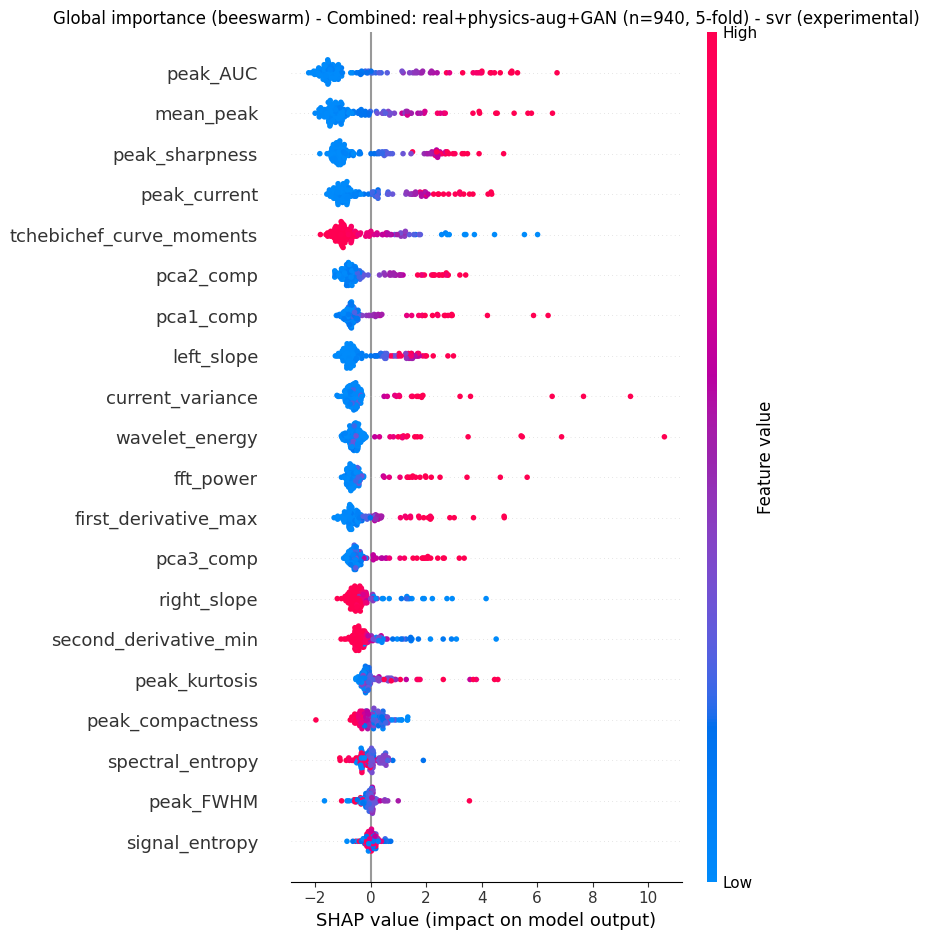

C:\Users\Sorana\AppData\Local\Temp\ipykernel_14276\4036230919.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(r['shap_values'], r['X_sample'], plot_type='bar', show=False)


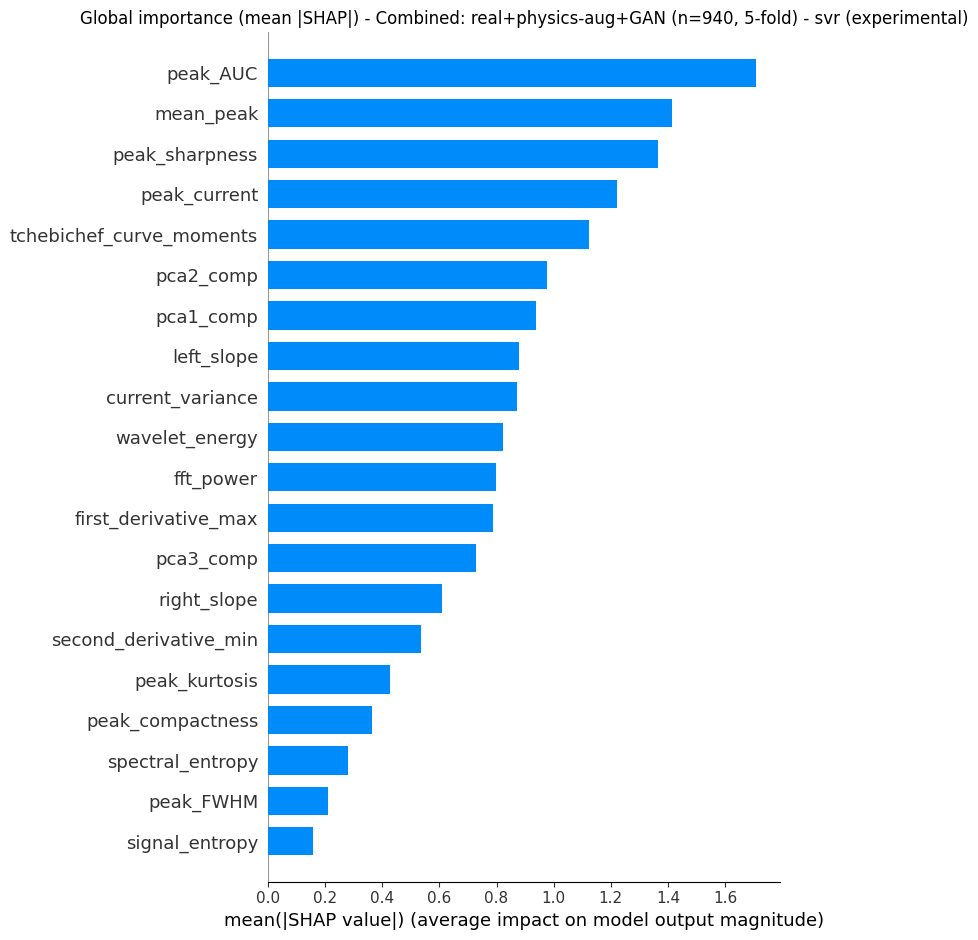

In [19]:
import matplotlib.pyplot as plt

for condition in SHAP_CONDITIONS:
    r = shap_results[condition]
    label = f"{CONDITION_LABELS[condition]} - {r['model']} ({r['suite']})"

    shap.summary_plot(r['shap_values'], r['X_sample'], show=False)
    plt.title(f"Global importance (beeswarm) - {label}")
    plt.tight_layout()
    plt.show()

    shap.summary_plot(r['shap_values'], r['X_sample'], plot_type='bar', show=False)
    plt.title(f"Global importance (mean |SHAP|) - {label}")
    plt.tight_layout()
    plt.show()

### 9.2 Local explanation: one concrete prediction

Signal with the highest true concentration for the `combined` condition's winning model.
Waterfall and force plot show the same decomposition (base rate -> final prediction, one feature contribution at a time) in SHAP layouts.

Example signal #3: true concentration = 93.36 uM, model prediction = 89.47 uM


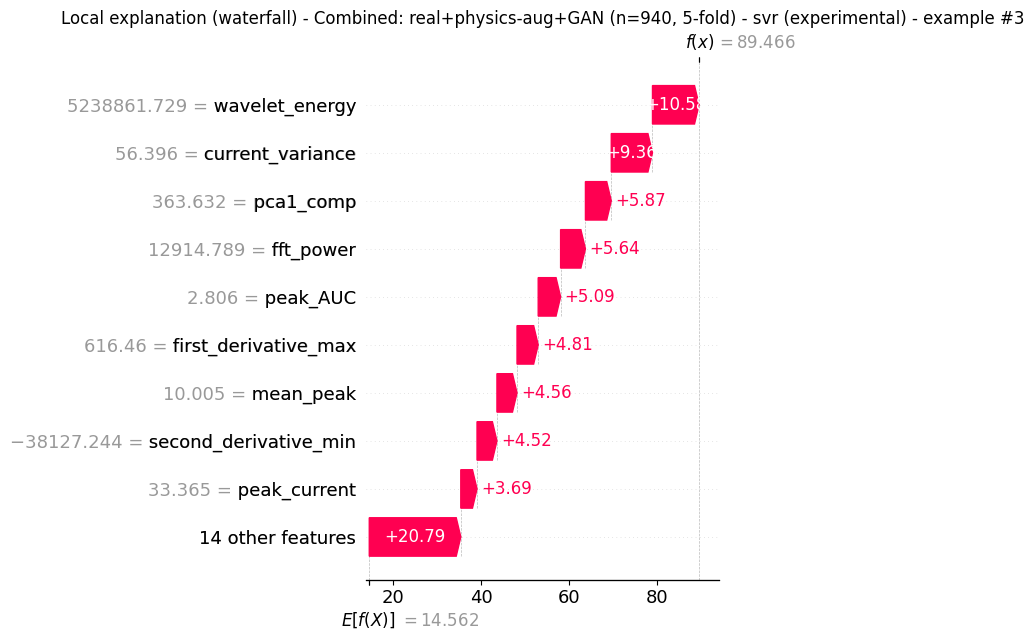

<Figure size 640x480 with 0 Axes>

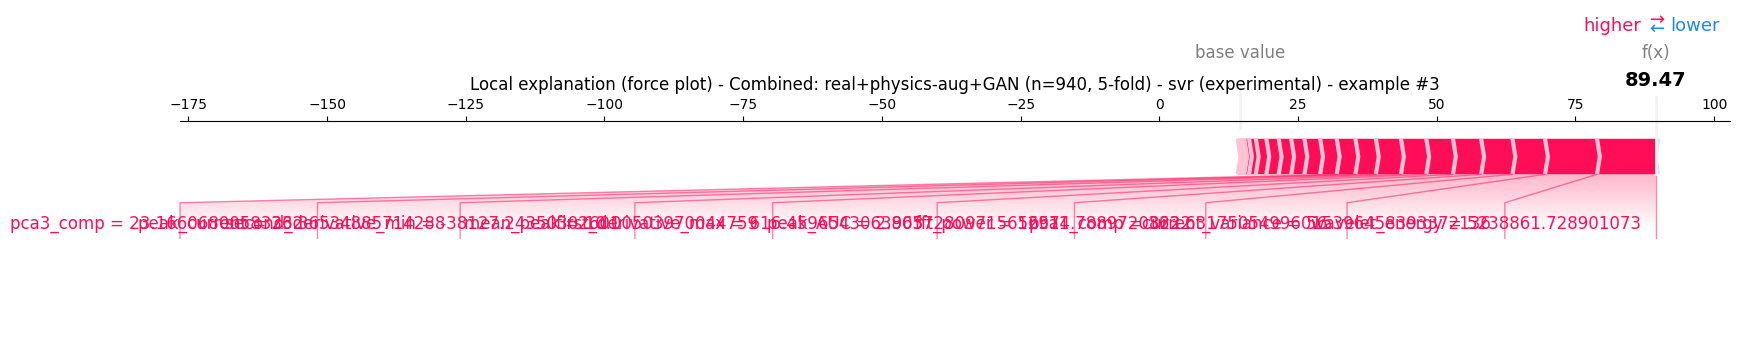

In [20]:
LOCAL_EXAMPLE_CONDITION = 'combined'
local = shap_results[LOCAL_EXAMPLE_CONDITION]
local_label = f"{CONDITION_LABELS[LOCAL_EXAMPLE_CONDITION]} - {local['model']} ({local['suite']})"

example_idx = int(np.argmax(local['y_sample'].to_numpy()))
sv = local['shap_values'][example_idx]
true_c = float(local['y_sample'].iloc[example_idx])
pred_c = float(local['pipe'].predict(local['X_sample'].iloc[[example_idx]])[0])
print(f"Example signal #{example_idx}: true concentration = {true_c:.2f} uM, "
      f"model prediction = {pred_c:.2f} uM")

shap.plots.waterfall(sv, show=False)
plt.title(f"Local explanation (waterfall) - {local_label} - example #{example_idx}")
plt.tight_layout()
plt.show()

plt.figure()
shap.force_plot(sv.base_values, sv.values, local['X_sample'].iloc[example_idx],
                 feature_names=list(local['X_sample'].columns), matplotlib=True, show=False)
plt.title(f"Local explanation (force plot) - {local_label} - example #{example_idx}")
plt.show()

### 9.3 Dependence (scatter) plots for the top features

The 3 highest mean-|SHAP| features of the same `combined` model, feature value on the x-axis vs. that feature's SHAP contribution (uM) on the y-axis  

(upward trend means higher feature values push the prediction up; downward means opposite)
Colour is the feature SHAP.plots.scatter auto-picks as the strongest interaction.

Top 3 features by mean |SHAP| - Combined: real+physics-aug+GAN (n=940, 5-fold) - svr (experimental):
peak_AUC          1.706912
mean_peak         1.412967
peak_sharpness    1.364719


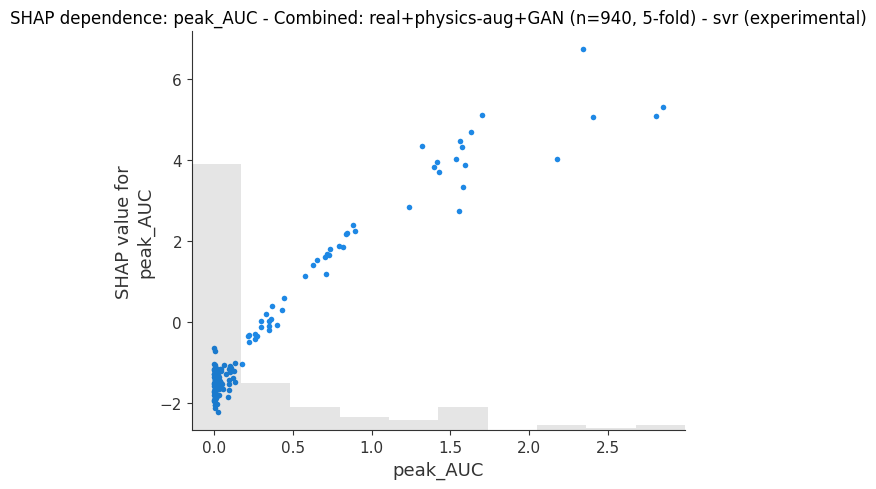

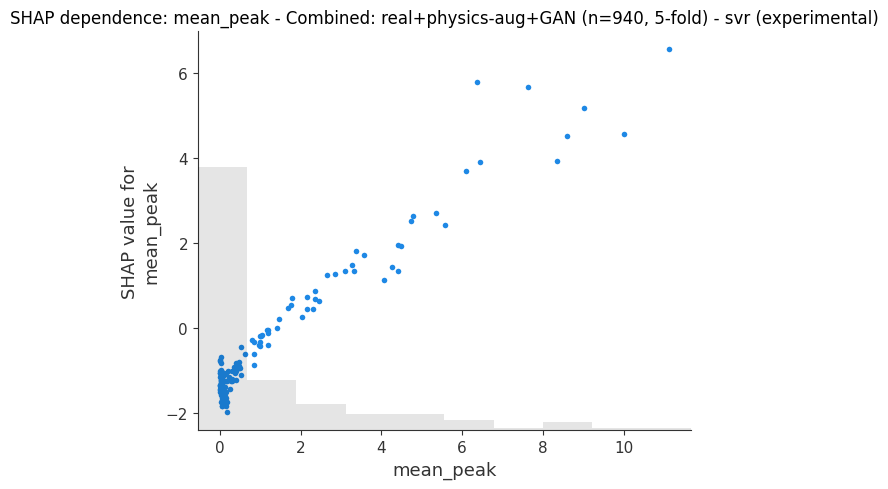

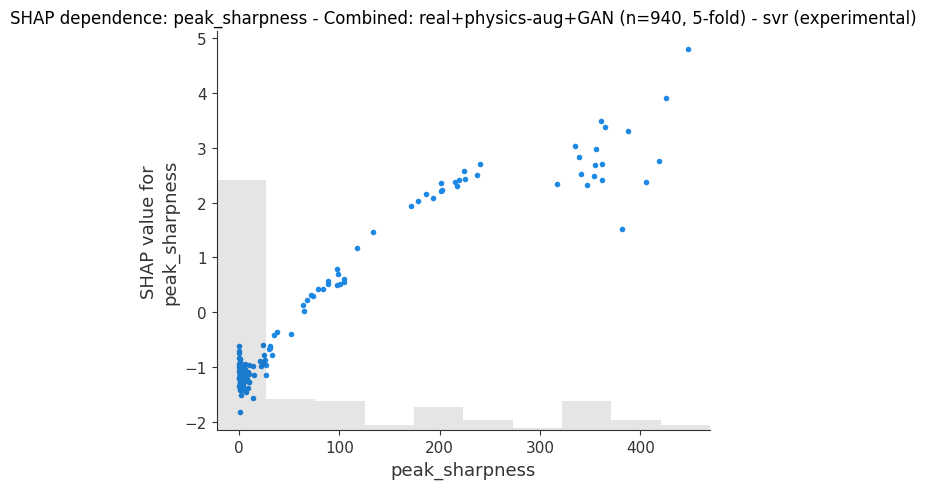

In [21]:
mean_abs_shap = pd.Series(np.abs(local['shap_values'].values).mean(axis=0),
                           index=local['X_sample'].columns).sort_values(ascending=False)
top_features = mean_abs_shap.head(3)
print(f"Top 3 features by mean |SHAP| - {local_label}:")
print(top_features.to_string())

for feat in top_features.index:
    shap.plots.scatter(local['shap_values'][:, feat], show=False)
    plt.title(f"SHAP dependence: {feat} - {local_label}")
    plt.tight_layout()
    plt.show()

In [ ]:
# Feature-importance ranking for every SHAP-explained model, 
# in numbers
for condition in SHAP_CONDITIONS:
    r = shap_results[condition]
    ranking = pd.Series(np.abs(r['shap_values'].values).mean(axis=0),
                         index=r['X_sample'].columns).sort_values(ascending=False)
    print(f"--- {condition} ({r['model']}, {r['suite']}) - top 5 by mean |SHAP| ---")
    print(ranking.head(5).to_string())
    print()

--- physics_aug (random_forest, experimental) - top 5 by mean |SHAP| ---
right_slope       1.242387
pca2_comp         1.069466
peak_AUC          1.065985
fft_power         1.046857
peak_sharpness    1.002217

--- gan (random_forest, experimental) - top 5 by mean |SHAP| ---
peak_AUC                1.904125
current_variance        1.878810
pca2_comp               1.755180
peak_sharpness          1.642599
first_derivative_max    1.608731

--- combined (svr, experimental) - top 5 by mean |SHAP| ---
peak_AUC                    1.706912
mean_peak                   1.412967
peak_sharpness              1.364719
peak_current                1.220454
tchebichef_curve_moments    1.122250

